In [ ]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Activation, BatchNormalization, Dense, Flatten, Lambda, Conv2DTranspose, Reshape
import numpy as np
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import utils
import keras.backend as K
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/LW3')
CODE_DIR = PROJECT_DIR / 'code'
CODE_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(CODE_DIR)

sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'LW3'))

Mounted at /content/drive


In [ ]:
batch_size = 100
latent_dim = 256
beta = 0.1
epochs = 100

SAVE_DIR = "/content/drive/MyDrive/LW3/saved_results"

In [ ]:
import tarfile
import pickle
import numpy as np
from pathlib import Path

archive_path = Path("/content/drive/MyDrive/LW3/data/cifar-10-python.tar.gz")
extract_dir = Path("/content/cifar10_manual")

print("Archive exists:", archive_path.exists())
print("Archive size:", archive_path.stat().st_size if archive_path.exists() else "not found")

extract_dir.mkdir(parents=True, exist_ok=True)

with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(extract_dir)

data_dir = extract_dir / "cifar-10-batches-py"
print("Extracted dir exists:", data_dir.exists())
print(list(data_dir.iterdir())[:5])

def load_cifar_batch(path):
    with open(path, "rb") as f:
        batch = pickle.load(f, encoding="latin1")

    x = batch["data"]
    y = np.array(batch["labels"])

    x = x.reshape(-1, 3, 32, 32)
    x = x.transpose(0, 2, 3, 1)

    return x, y.reshape(-1, 1)

x_parts = []
y_parts = []

for i in range(1, 6):
    x_batch, y_batch = load_cifar_batch(data_dir / f"data_batch_{i}")
    x_parts.append(x_batch)
    y_parts.append(y_batch)

X_train = np.concatenate(x_parts, axis=0)
Y_train = np.concatenate(y_parts, axis=0)

X_test, Y_test = load_cifar_batch(data_dir / "test_batch")

print("X_train shape", X_train.shape)
print("Y_train shape", Y_train.shape)
print("X_test shape", X_test.shape)
print("Y_test shape", Y_test.shape)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

Archive exists: True
Archive size: 170498071


/tmp/ipykernel_2493/2362503580.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


Extracted dir exists: True
[PosixPath('/content/cifar10_manual/cifar-10-batches-py/data_batch_3'), PosixPath('/content/cifar10_manual/cifar-10-batches-py/readme.html'), PosixPath('/content/cifar10_manual/cifar-10-batches-py/data_batch_2'), PosixPath('/content/cifar10_manual/cifar-10-batches-py/data_batch_4'), PosixPath('/content/cifar10_manual/cifar-10-batches-py/test_batch')]
X_train shape (50000, 32, 32, 3)
Y_train shape (50000, 1)
X_test shape (10000, 32, 32, 3)
Y_test shape (10000, 1)


In [ ]:
def add_gaussian_noise(images, stddev=0.1):
    noise = np.random.normal(loc=0.0, scale=stddev, size=images.shape)
    noisy = images + noise
    return np.clip(noisy, 0.0, 1.0)
X_train_noisy = add_gaussian_noise(X_train, stddev=0.1)

In [ ]:
class Sampling(keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        # z_log_var = tf.clip_by_value(z_log_var, -10.0, 10.0)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))

        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        kl_loss = 0.5 * tf.reduce_sum(
            tf.exp(z_log_var) - z_log_var + tf.square(z_mean) - 1,
            axis=-1
        )

        self.add_loss(beta * tf.reduce_mean(kl_loss))


        return z


def make_model():
    input_img = Input((32,32,3))

    x = Conv2D(32, (5,5), strides = 2, padding = "same")(input_img)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(64, (5,5), strides = 2, padding = "same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(128, (5,5), strides = 2, padding = "same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Flatten()(x)

    z_mean = Dense(latent_dim)(x)
    z_log_var = Dense(latent_dim)(x)

    h = Sampling()([z_mean, z_log_var])

    input_dec = Input(shape=(latent_dim,))

    d = Reshape((2,2,64))(input_dec)

    d = Conv2DTranspose(256, (3, 3), strides=2, padding="same")(d)
    d = BatchNormalization()(d)
    d = Activation("relu")(d)

    d = Conv2DTranspose(128, (3, 3), strides=2, padding="same")(d)
    d = BatchNormalization()(d)
    d = Activation("relu")(d)

    d = Conv2DTranspose(64, (3, 3), strides=2, padding="same")(d)
    d = BatchNormalization()(d)
    d = Activation("relu")(d)

    d = Conv2DTranspose(32, (3, 3), strides=2, padding="same")(d)
    d = BatchNormalization()(d)
    d = Activation("relu")(d)

    decoded = Conv2DTranspose(3, (3, 3), strides=1, activation="sigmoid", padding="same")(d)

    encoder = keras.Model(input_img, h, name = "encoder")
    decoder = keras.Model(input_dec, decoded, name = "decoder")
    mean_encoder = keras.Model(input_img, z_mean, name = "encoder_mean")
    stats_encoder = keras.Model(input_img, [z_mean, z_log_var], name="stats_encoder")
    vae = keras.Model(input_img, decoder(encoder(input_img)), name = "vae")

    def reconstruction_loss(x, y):
        x = tf.reshape(x, shape=(tf.shape(x)[0], 32 * 32 * 3))
        y = tf.reshape(y, shape=(tf.shape(y)[0], 32 * 32 * 3))

        return tf.reduce_sum(tf.square(x - y), axis=-1)

    vae.summary()
    vae.compile(loss = reconstruction_loss, optimizer="adam")

    return mean_encoder, stats_encoder, encoder, decoder, vae

In [ ]:
mean_encoder, stats_encoder, encoder, decoder, vae = make_model()

vae.fit(X_train_noisy, X_train, epochs = epochs, batch_size=batch_size, shuffle = True)

decoded_imgs = vae.predict(X_test, batch_size=batch_size)

score = vae.evaluate(X_test, X_test, batch_size=batch_size)
print('Loss:', score)


Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 256)            │     1,308,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │       537,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,846,403 (7.04 MB)

 Trainable params: 1,844,995 (7.04 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 68.8849
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 46.3797
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 42.3058
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 40.3431
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 39.3601
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 38.5394
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 38.0590
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 37.5998
Epoch 9/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 37.3013
Epoch 10/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 37.0262
Epoch 11/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 36.7663
Epoch 12/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 36.4632
Epoch 13/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 36.2844
Epoch 14/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 36.1323
Epoch 15/100

In [ ]:
vae.save(f"{SAVE_DIR}/2_VAE_23_for_CNN.keras")
decoder.save(f"{SAVE_DIR}/2_decoder_23_for_CNN.keras")
mean_encoder.save(f"{SAVE_DIR}/2_mean_encoder_23_for_CNN.keras")
stats_encoder.save(f"{SAVE_DIR}/2_stats_encoder_23_for_CNN.keras")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.layers import Embedding

class Sampling(keras.layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            z_log_var = tf.clip_by_value(z_log_var, -10.0, 10.0)
            epsilon = tf.random.normal(shape=tf.shape(z_mean))

            z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

            kl_loss = 0.5 * tf.reduce_sum(
                tf.exp(z_log_var) - z_log_var + tf.square(z_mean) - 1,
                axis=-1
            )

            self.add_loss(beta * tf.reduce_mean(kl_loss))


            return z

vae = keras.models.load_model(
    f"{SAVE_DIR}/VAE_23_for_CNN.keras",
    custom_objects={"Sampling": Sampling},
    compile=False
)

decoder = keras.models.load_model(
    f"{SAVE_DIR}/decoder_23_for_CNN.keras",
    compile=False
)

mean_encoder = keras.models.load_model(
    f"{SAVE_DIR}/mean_encoder_23_for_CNN.keras",
    compile=False
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


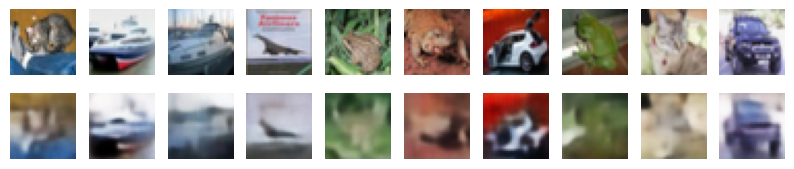

In [ ]:
%matplotlib inline

decoded_imgs = vae.predict(X_test, batch_size=batch_size)

n = 10

plt.figure(figsize=(n, 2))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    ax.axis("off")

    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i])
    ax.axis("off")

plt.show()

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
nb_classes = 10

# z_mean для всех обучающих картинок
z_train = mean_encoder.predict(X_train, batch_size=batch_size)

y_train_flat = Y_train.squeeze()

class_means = []
class_stds = []

for class_id in range(nb_classes):
    class_vectors = z_train[y_train_flat == class_id]

    class_mean = np.mean(class_vectors, axis=0)
    class_std = np.std(class_vectors, axis=0)

    class_means.append(class_mean)
    class_stds.append(class_std)

class_means = np.array(class_means)
class_stds = np.array(class_stds)

print("class_means shape:", class_means.shape)
print("class_stds shape:", class_stds.shape)

500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
class_means shape: (10, 256)
class_stds shape: (10, 256)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step


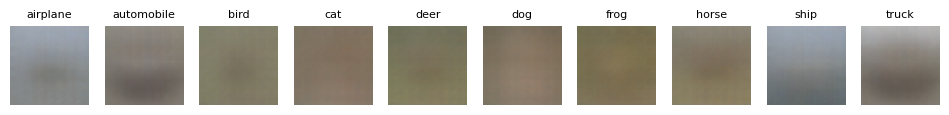

In [ ]:
mean_images = decoder.predict(class_means, batch_size=10)

plt.figure(figsize=(12, 2))

for i in range(nb_classes):
    ax = plt.subplot(1, nb_classes, i + 1)
    plt.imshow(mean_images[i])
    plt.title(class_names[i], fontsize=8)
    ax.axis("off")

plt.show()

In [ ]:
n_per_class = 5000
noise_scale = 0.3

generated_images = []
generated_labels = []

for class_id in range(nb_classes):
    mean_z = class_means[class_id]
    std_z = class_stds[class_id]

    noise = np.random.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, latent_dim)
    )

    z_samples = mean_z + noise_scale * std_z * noise

    imgs = decoder.predict(z_samples, batch_size=batch_size)

    generated_images.append(imgs)
    generated_labels.append(np.full((n_per_class,), class_id))

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
X_generated = np.concatenate(generated_images, axis=0)
Y_generated_int = np.concatenate(generated_labels, axis=0)

print("X_generated shape:", X_generated.shape)
print("Y_generated_int shape:", Y_generated_int.shape)

X_generated shape: (50000, 32, 32, 3)
Y_generated_int shape: (50000,)


In [ ]:
Y_generated = utils.to_categorical(Y_generated_int, nb_classes)
print("Y_generated shape:", Y_generated.shape)

Y_generated shape: (50000, 10)


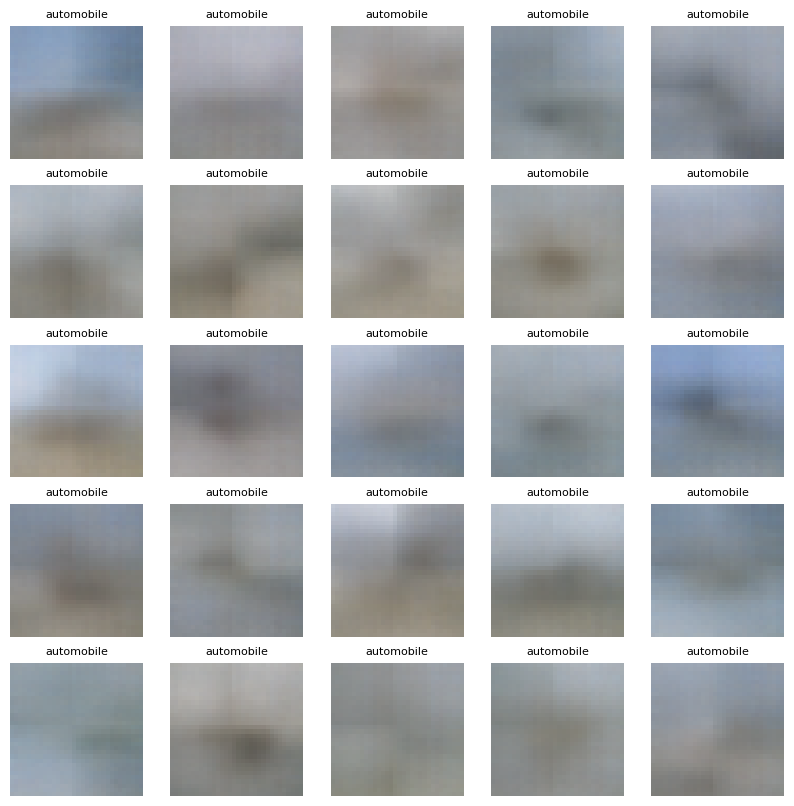

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(X_generated[i])
    plt.title(class_names[Y_generated_int[i+6000]], fontsize=8)
    ax.axis("off")

plt.show()

In [ ]:
# 1. Подготовка настоящих test-меток

Y_test_cat = utils.to_categorical(Y_test.squeeze(), nb_classes)

print("X_generated:", X_generated.shape)
print("Y_generated:", Y_generated.shape)
print("X_test:", X_test.shape)
print("Y_test_cat:", Y_test_cat.shape)

X_generated: (50000, 32, 32, 3)
Y_generated: (50000, 10)
X_test: (10000, 32, 32, 3)
Y_test_cat: (10000, 10)


In [ ]:
# 2. CNN-классификатор из первой ЛР

def make_cnn_classifier():
    model = keras.models.Sequential()

    model.add(keras.layers.Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    ))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPool2D((2, 2)))
    model.add(keras.layers.Dropout(0.25))

    model.add(keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPool2D((2, 2)))
    model.add(keras.layers.Dropout(0.25))

    model.add(keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPool2D((2, 2)))
    model.add(keras.layers.Dropout(0.25))

    model.add(keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPool2D((2, 2)))
    model.add(keras.layers.Dropout(0.25))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(128, activation='relu'))
    model.add(keras.layers.Dropout(0.3))
    model.add(keras.layers.Dense(10, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


cnn_generated = make_cnn_classifier()
cnn_generated.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,308,586 (4.99 MB)

 Trainable params: 1,306,666 (4.98 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# 3. Обучение CNN на VAE-generated данных

cnn_epochs = 15
cnn_batch_size = 128

history_generated = cnn_generated.fit(
    X_generated,
    Y_generated,
    batch_size=cnn_batch_size,
    epochs=cnn_epochs,
    shuffle=True,
    validation_data=(X_test, Y_test_cat)
)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.7905 - loss: 0.5962 - val_accuracy: 0.3069 - val_loss: 3.3534
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8718 - loss: 0.3557 - val_accuracy: 0.2096 - val_loss: 12.6907
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8836 - loss: 0.3216 - val_accuracy: 0.2293 - val_loss: 11.0347
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8943 - loss: 0.2908 - val_accuracy: 0.2269 - val_loss: 9.7969
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8990 - loss: 0.2808 - val_accuracy: 0.1873 - val_loss: 16.0586
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9056 - loss: 0.2578 - val_accuracy: 0.1932 - val_loss: 17.7286
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9082 - loss: 0.2530 - val_accuracy: 0.2375 - val_loss: 11.9324
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9121 - loss: 0.2413 - va

In [ ]:
# 4. Оценка на настоящем CIFAR-10

cnn_batch_size = 128
test_loss, test_acc = cnn_generated.evaluate(
    X_test,
    Y_test_cat,
    batch_size=cnn_batch_size
)

print("CNN trained on generated data")
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2052 - loss: 18.4100
CNN trained on generated data
Test loss: 18.410037994384766
Test accuracy: 0.20520000159740448


In [ ]:
cnn_generated.save("../saved_results/CNN_best_26.keras")

In [ ]:
vae.save(f"{SAVE_DIR}/VAE_26_for_CNN.keras")
decoder.save(f"{SAVE_DIR}/decoder_26_for_CNN.keras")
mean_encoder.save(f"{SAVE_DIR}/mean_encoder_26_for_CNN.keras")
stats_encoder.save(f"{SAVE_DIR}/stats_encoder_26_for_CNN.keras")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.layers import Embedding

class Sampling(keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        z_log_var = tf.clip_by_value(z_log_var, -10.0, 10.0)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))

        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        kl_loss = 0.5 * tf.reduce_sum(
            tf.exp(z_log_var) - z_log_var + tf.square(z_mean) - 1,
            axis=-1
        )

        self.add_loss(beta * tf.reduce_mean(kl_loss))


        return z

vae = keras.models.load_model(
    f"{SAVE_DIR}/VAE_26_for_CNN.keras",
    custom_objects={"Sampling": Sampling},
    compile=False
)

decoder = keras.models.load_model(
    f"{SAVE_DIR}/decoder_26_for_CNN.keras",
    compile=False
)

mean_encoder = keras.models.load_model(
    f"{SAVE_DIR}/mean_encoder_26_for_CNN.keras",
    compile=False
)

cnn_generated = keras.models.load_model(
    f"{SAVE_DIR}/CNN_best_26.keras",
    compile=True
)
